<a href="https://colab.research.google.com/github/2pson-B/2pson-B/blob/main/modelisation_scr_marche.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# SCR DE MARCHÉ - Contrat d'épargne avec garantie de capital





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import eval_legendre
import time
from scipy.linalg import solve

np.random.seed(42)

# Paramètres du contrat

In [ ]:



T = 2             # maturité du contrat (en années)
sigma_i = 0.25    # volatilité implicite (risque neutre)
sigma_r = 0.15    # volatilité historique (monde réel)
mu = 0.02         # rendement espéré (monde historique)
r = 0.01          # taux sans risque
r_g = 0.005       # taux technique garanti

VM0 = 110         # valeur initiale du fond
PM0 = 100         # provision mathématique initiale (montant investi)
x = 0.30          # proportion investie en actif risqué
R = PM0 / VM0     # quote-part de l'assuré dans le fond

S0 = 1.0          # valeur initiale normalisée du sous-jacent

In [ ]:
# Strike du put européen
K = R * VM0 * np.exp(r_g * T) - (1 - x) * R * VM0 * np.exp(r * T)
# Nominal de l'actif risqué investi
nominal_risque = x * R * VM0

print("=== PARAMÈTRES ===")
print(f"T={T}, sigma_i={sigma_i}, sigma_r={sigma_r}, mu={mu}, r={r}, r_g={r_g}")
print(f"VM0={VM0}, PM0={PM0}, x={x}, R={R:.4f}")
print(f"Strike K = {K:.4f}")
print(f"Nominal actif risqué = {nominal_risque:.4f}")

=== PARAMÈTRES ===
T=2, sigma_i=0.25, sigma_r=0.15, mu=0.02, r=0.01, r_g=0.005
VM0=110, PM0=100, x=0.3, R=0.9091
Strike K = 29.5909
Nominal actif risqué = 30.0000


In [ ]:

# =============================================================
# FORMULES ANALYTIQUES (BLACK-SCHOLES)
# =============================================================

def prix_put_bs(S, K, r, sigma, T):
    """Prix d'un put européen par Black-Scholes"""
    if T <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    prix = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return prix

def prix_call_bs(S, K, r, sigma, T):
    """Prix d'un call européen par Black-Scholes"""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    prix = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return prix


In [ ]:

# =============================================================
# QUESTION 1 : CALCUL DE NAV0
# =============================================================

def calcul_NAV0():
    """
    NAV0 = actif0 - passif0
    Actif : VM0 (valeur du marché)
    Passif : valeur actualisée de (BE + Option) sous Q
    """
    # Valeur actuelle du fond garanti (partie BE)
    # BE_T = R * VM0 * (x*S_T + (1-x)*e^{rT})
    # Son espérance sous Q actualisée = R * VM0 * (x*S0 + (1-x)*e^{rT}*e^{-rT})
    #                                 = R * VM0 * (x*S0 + (1-x))
    valeur_BE0 = R * VM0 * (x * S0 + (1 - x))  # actualisé

    # Valeur actuelle du put (option de garantie)
    # Le sous-jacent du put a pour valeur initiale : nominal_risque * S0
    S_put = nominal_risque * S0
    valeur_put0 = prix_put_bs(S_put, K, r, sigma_i, T)

    # Passif total actualisé
    passif0 = valeur_BE0 + valeur_put0

    # Actif = VM0
    actif0 = VM0

    NAV0 = actif0 - passif0

    print("\n=== CALCUL DE NAV0 ===")
    print(f"Valeur actuelle BE     = {valeur_BE0:.4f}")
    print(f"Valeur actuelle Put    = {valeur_put0:.4f}")
    print(f"Passif total actualisé = {passif0:.4f}")
    print(f"Actif (VM0)            = {actif0:.4f}")
    print(f"NAV0                   = {NAV0:.4f}")

    return NAV0

NAV0 = calcul_NAV0()


=== CALCUL DE NAV0 ===
Valeur actuelle BE     = 100.0000
Valeur actuelle Put    = 3.6608
Passif total actualisé = 103.6608
Actif (VM0)            = 110.0000
NAV0                   = 6.3392


In [ ]:


# =============================================================
# FONCTIONS UTILITAIRES : SIMULATION ET CALCUL DES PAYOFFS
# =============================================================

def simuler_sous_jacent(S_depart, nb_sim, dt, sigma, derive):
    """
    Simule nb_sim valeurs de S_{t+dt} à partir de S_depart
    sous un mouvement Brownien géométrique
    derive : mu (historique) ou r (risque neutre)
    """
    Z = np.random.standard_normal(nb_sim)
    S_fin = S_depart * np.exp((derive - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return S_fin

def calculer_VM_T(S_T):
    """Valeur du fond à maturité"""
    return VM0 * (x * S_T + (1 - x) * np.exp(r * T))

def calculer_BE_T(S_T):
    """Partie garantie (best estimate) à maturité"""
    return R * VM0 * (x * S_T + (1 - x) * np.exp(r * T))

def calculer_put_T(S_T):
    """Payoff du put à maturité"""
    # Sous-jacent du put = nominal_risque * S_T
    return np.maximum(K - nominal_risque * S_T, 0)

def calculer_NAV1_analytique(S1):
    """
    Calcule NAV1 de façon analytique (Black-Scholes) pour un vecteur S1
    Utile pour vérification
    """
    # Valeur actuelle du fond garanti à t=1
    valeur_BE1 = R * VM0 * (x * S1 + (1 - x) * np.exp(r * T))  # pas d'actualisation car BE est linéaire
    # Valeur actuelle du put à t=1 (maturité restante = T-1 = 1 an)
    S_put1 = nominal_risque * S1
    valeur_put1 = np.array([prix_put_bs(s, K, r, sigma_i, T - 1) for s in S_put1])

    passif1 = valeur_BE1 + valeur_put1
    actif1 = VM0 * (x * S1 + (1 - x) * np.exp(r * 1))  # valeur du fond à t=1
    NAV1 = actif1 - passif1
    return NAV1

In [ ]:






# =============================================================
# MÉTHODE 1 : SIMULATIONS DANS LES SIMULATIONS (SdS)
# =============================================================

def methode_SdS(N=1000, M=500, afficher=True):
    """
    Simulations dans les Simulations
    N : nombre de simulations primaires (jusqu'à t=1, monde historique)
    M : nombre de simulations secondaires (de t=1 à T, monde risque neutre)
    """
    debut = time.time()

    # Étape 1 : Simuler N trajectoires jusqu'à t=1 (monde historique)
    S1_sim = simuler_sous_jacent(S0, N, dt=1, sigma=sigma_r, derive=mu)

    # Étape 2 : Pour chaque simulation primaire k, estimer NAV1 par Monte-Carlo
    NAV1_sim = np.zeros(N)

    for k in range(N):
        S1_k = S1_sim[k]

        # Simuler M trajectoires de t=1 à T (monde risque neutre)
        ST_sim = simuler_sous_jacent(S1_k, M, dt=T - 1, sigma=sigma_i, derive=r)

        # Calculer les payoffs
        VM_T = calculer_VM_T(ST_sim)
        BE_T = calculer_BE_T(ST_sim)
        put_T = calculer_put_T(ST_sim)

        # NAV1 estimée (actualisée de T à t=1)
        NAV1_sim[k] = np.exp(-r * (T - 1)) * np.mean(VM_T - BE_T - put_T)

    # Étape 3 : Calculer la VaR à 99.5% de NAV1 actualisée à t=0
    NAV1_actualisee = NAV1_sim / (1 + r)
    VaR_995 = np.percentile(NAV1_actualisee, 0.5)  # quantile 0.5% (bas de distribution)

    SCR = NAV0 - VaR_995
    duree = time.time() - debut

    if afficher:
        print(f"\n=== MÉTHODE SdS (N={N}, M={M}) ===")
        print(f"Moyenne NAV1          = {np.mean(NAV1_sim):.4f}")
        print(f"Std NAV1              = {np.std(NAV1_sim):.4f}")
        print(f"VaR 99.5% de NAV1/1+r = {VaR_995:.4f}")
        print(f"SCR                   = {SCR:.4f}")
        print(f"Temps de calcul       = {duree:.2f}s")

        # Intervalle de confiance pour la VaR (bootstrap simple)
        nb_bootstrap = 200
        VaR_bootstrap = []
        for _ in range(nb_bootstrap):
            echantillon = np.random.choice(NAV1_actualisee, size=N, replace=True)
            VaR_bootstrap.append(np.percentile(echantillon, 0.5))
        IC_bas = np.percentile(VaR_bootstrap, 2.5)
        IC_haut = np.percentile(VaR_bootstrap, 97.5)
        print(f"IC 95% VaR            = [{IC_bas:.4f}, {IC_haut:.4f}]")

    return SCR, NAV1_sim, duree

In [ ]:

# =============================================================
# POLYNÔMES DE LEGENDRE ORTHONORMÉS (base LSMC)
# =============================================================

def normaliser_S(S):
    """Normalise S dans [-1, 1] pour l'utilisation des polynômes de Legendre"""
    S_min, S_max = np.min(S), np.max(S)
    return 2 * (S - S_min) / (S_max - S_min) - 1, S_min, S_max

def base_legendre(S_norm, degre_max):
    """
    Construit la matrice de la base de polynômes de Legendre orthonormés
    Retourne une matrice (N, degre_max+1)
    """
    N = len(S_norm)
    Phi = np.zeros((N, degre_max + 1))
    for j in range(degre_max + 1):
        # Polynôme de Legendre de degré j, normalisé
        Phi[:, j] = eval_legendre(j, S_norm) * np.sqrt(2 * j + 1) / np.sqrt(2)
    return Phi

In [ ]:

# =============================================================
# MÉTHODE 2 : LSMC (Least-Square Monte Carlo)
# =============================================================

def methode_LSMC(N=1000, M=50, degre=5, afficher=True):
    """
    Méthode LSMC
    N : simulations primaires
    M : simulations secondaires (petit)
    degre : degré max des polynômes
    """
    debut = time.time()

    # Étape 1 : Simuler N trajectoires jusqu'à t=1 (monde historique)
    S1_sim = simuler_sous_jacent(S0, N, dt=1, sigma=sigma_r, derive=mu)

    # Étape 2 : Estimer NAV1 bruitée avec peu de simulations secondaires
    NAV1_bruitee = np.zeros(N)

    for k in range(N):
        S1_k = S1_sim[k]
        ST_sim = simuler_sous_jacent(S1_k, M, dt=T - 1, sigma=sigma_i, derive=r)

        VM_T = calculer_VM_T(ST_sim)
        BE_T = calculer_BE_T(ST_sim)
        put_T = calculer_put_T(ST_sim)

        NAV1_bruitee[k] = np.exp(-r * (T - 1)) * np.mean(VM_T - BE_T - put_T)

    # Étape 3 : Régression sur base de Legendre
    S1_norm, S_min, S_max = normaliser_S(S1_sim)
    Phi = base_legendre(S1_norm, degre)

    # Moindres carrés : alpha = (Phi'Phi)^{-1} Phi' NAV1_bruitee
    alpha, _, _, _ = np.linalg.lstsq(Phi, NAV1_bruitee, rcond=None)

    # Étape 4 : Utiliser la valeur ajustée pour estimer la distribution
    NAV1_ajustee = Phi @ alpha

    # Calcul du SCR
    NAV1_actualisee = NAV1_ajustee / (1 + r)
    VaR_995 = np.percentile(NAV1_actualisee, 0.5)
    SCR = NAV0 - VaR_995

    duree = time.time() - debut

    if afficher:
        print(f"\n=== MÉTHODE LSMC (N={N}, M={M}, degré={degre}) ===")
        print(f"Coefficients alpha     = {np.round(alpha, 4)}")
        print(f"Moyenne NAV1 ajustée   = {np.mean(NAV1_ajustee):.4f}")
        print(f"Std NAV1 ajustée       = {np.std(NAV1_ajustee):.4f}")
        print(f"VaR 99.5% de NAV1/1+r  = {VaR_995:.4f}")
        print(f"SCR                    = {SCR:.4f}")
        print(f"Temps de calcul        = {duree:.2f}s")
        print(f"R² de la régression    = {1 - np.sum((NAV1_bruitee - NAV1_ajustee)**2) / np.sum((NAV1_bruitee - np.mean(NAV1_bruitee))**2):.4f}")

    return SCR, NAV1_ajustee, alpha, duree



In [ ]:
# =============================================================
# MÉTHODE 3 : MIXTE (SIMULATIONS / EDP - BLACK-SCHOLES ANALYTIQUE)
# =============================================================

def methode_mixte(N=1000, afficher=True):
    """
    Méthode mixte : EDP (formule fermée Black-Scholes) + simulations
    On utilise la formule analytique de Black-Scholes pour calculer u(t=1, S1)
    """
    debut = time.time()

    # Étape 1 : Simuler N trajectoires jusqu'à t=1 (monde historique)
    S1_sim = simuler_sous_jacent(S0, N, dt=1, sigma=sigma_r, derive=mu)

    # Étape 2 : Appliquer la fonction u(t=1, S1) analytiquement
    # u(t, S) = e^{-r(T-t)} * E^Q[put_T | S_t = S]
    # = prix Black-Scholes du put avec sous-jacent S_put = nominal_risque * S

    NAV1_analytique = np.zeros(N)

    for k in range(N):
        S1_k = S1_sim[k]

        # Valeur du fond à t=1
        actif1_k = VM0 * (x * S1_k + (1 - x) * np.exp(r * 1))

        # Valeur actuelle (à t=1) du passif BE
        valeur_BE1_k = R * VM0 * (x * S1_k + (1 - x) * np.exp(r * T))

        # Valeur actuelle (à t=1) du put via Black-Scholes (EDP résolue analytiquement)
        S_put1_k = nominal_risque * S1_k
        valeur_put1_k = prix_put_bs(S_put1_k, K, r, sigma_i, T - 1)

        NAV1_analytique[k] = actif1_k - valeur_BE1_k - valeur_put1_k

    # Calcul du SCR
    NAV1_actualisee = NAV1_analytique / (1 + r)
    VaR_995 = np.percentile(NAV1_actualisee, 0.5)
    SCR = NAV0 - VaR_995

    duree = time.time() - debut

    if afficher:
        print(f"\n=== MÉTHODE MIXTE EDP (N={N}) ===")
        print(f"Moyenne NAV1           = {np.mean(NAV1_analytique):.4f}")
        print(f"Std NAV1               = {np.std(NAV1_analytique):.4f}")
        print(f"VaR 99.5% de NAV1/1+r  = {VaR_995:.4f}")
        print(f"SCR                    = {SCR:.4f}")
        print(f"Temps de calcul        = {duree:.2f}s")

    return SCR, NAV1_analytique, duree



In [ ]:
# =============================================================
# EXÉCUTION DES TROIS MÉTHODES
# =============================================================

print("\n" + "="*60)
print("CALCUL DU SCR PAR LES 3 MÉTHODES")
print("="*60)

SCR_SdS, NAV1_SdS, t_SdS = methode_SdS(N=2000, M=500)
SCR_LSMC, NAV1_LSMC, alpha_opt, t_LSMC = methode_LSMC(N=2000, M=50, degre=5)
SCR_mixte, NAV1_mixte, t_mixte = methode_mixte(N=2000)




CALCUL DU SCR PAR LES 3 MÉTHODES

=== MÉTHODE SdS (N=2000, M=500) ===
Moyenne NAV1          = 7.3759
Std NAV1              = 2.2065
VaR 99.5% de NAV1/1+r = 0.1204
SCR                   = 6.2188
Temps de calcul       = 0.31s
IC 95% VaR            = [-0.5602, 0.8270]

=== MÉTHODE LSMC (N=2000, M=50, degré=5) ===
Coefficients alpha     = [ 1.15146e+01  4.81650e+00 -1.65710e+00  3.69300e-01  2.70000e-03
 -7.28000e-02]
Moyenne NAV1 ajustée   = 7.3030
Std NAV1 ajustée       = 2.2352
VaR 99.5% de NAV1/1+r  = -0.0297
SCR                    = 6.3689
Temps de calcul        = 0.18s
R² de la régression    = 0.9360

=== MÉTHODE MIXTE EDP (N=2000) ===
Moyenne NAV1           = 6.5372
Std NAV1               = 2.2525
VaR 99.5% de NAV1/1+r  = -0.2506
SCR                    = 6.5898
Temps de calcul        = 0.74s


In [ ]:

# =============================================================
# QUESTION 1 : IMPACT DE N, M ET d
# =============================================================

print("\n" + "="*60)
print("ÉTUDE DES PARAMÈTRES N, M, d")
print("="*60)

# Impact de N (nombre de simulations primaires)
liste_N = [500, 1000, 2000, 5000]
SCR_vs_N = []
print("\nImpact de N (M=100 fixé, degré=5 pour LSMC) :")
for n in liste_N:
    scr, _, _ = methode_SdS(N=n, M=100, afficher=False)
    SCR_vs_N.append(scr)
    print(f"  N={n:5d} -> SCR SdS = {scr:.4f}")

# Impact de M (simulations secondaires)
liste_M = [10, 50, 100, 500, 1000]
SCR_vs_M_SdS = []
SCR_vs_M_LSMC = []
print("\nImpact de M (N=2000 fixé, degré=5 pour LSMC) :")
for m in liste_M:
    scr_sds, _, _ = methode_SdS(N=2000, M=m, afficher=False)
    scr_lsmc, _, _, _ = methode_LSMC(N=2000, M=m, degre=5, afficher=False)
    SCR_vs_M_SdS.append(scr_sds)
    SCR_vs_M_LSMC.append(scr_lsmc)
    print(f"  M={m:4d} -> SCR SdS={scr_sds:.4f}, SCR LSMC={scr_lsmc:.4f}")

# Impact du degré d des polynômes (LSMC)
liste_degre = [1, 2, 3, 5, 7, 10]
SCR_vs_degre = []
print("\nImpact du degré d (N=2000, M=50 fixés) :")
for d in liste_degre:
    scr, _, _, _ = methode_LSMC(N=2000, M=50, degre=d, afficher=False)
    SCR_vs_degre.append(scr)
    print(f"  degré={d:2d} -> SCR LSMC = {scr:.4f}")




ÉTUDE DES PARAMÈTRES N, M, d

Impact de N (M=100 fixé, degré=5 pour LSMC) :
  N=  500 -> SCR SdS = 6.3500
  N= 1000 -> SCR SdS = 5.8255
  N= 2000 -> SCR SdS = 5.9252
  N= 5000 -> SCR SdS = 6.4339

Impact de M (N=2000 fixé, degré=5 pour LSMC) :
  M=  10 -> SCR SdS=7.3578, SCR LSMC=5.8627
  M=  50 -> SCR SdS=6.1427, SCR LSMC=6.5153
  M= 100 -> SCR SdS=6.2640, SCR LSMC=5.7509
  M= 500 -> SCR SdS=6.0249, SCR LSMC=6.4860
  M=1000 -> SCR SdS=5.9801, SCR LSMC=5.6153

Impact du degré d (N=2000, M=50 fixés) :
  degré= 1 -> SCR LSMC = 3.8630
  degré= 2 -> SCR LSMC = 5.9953
  degré= 3 -> SCR LSMC = 6.1557
  degré= 5 -> SCR LSMC = 6.5194
  degré= 7 -> SCR LSMC = 6.3881
  degré=10 -> SCR LSMC = 6.2421



COMPARAISON DES MÉTHODES


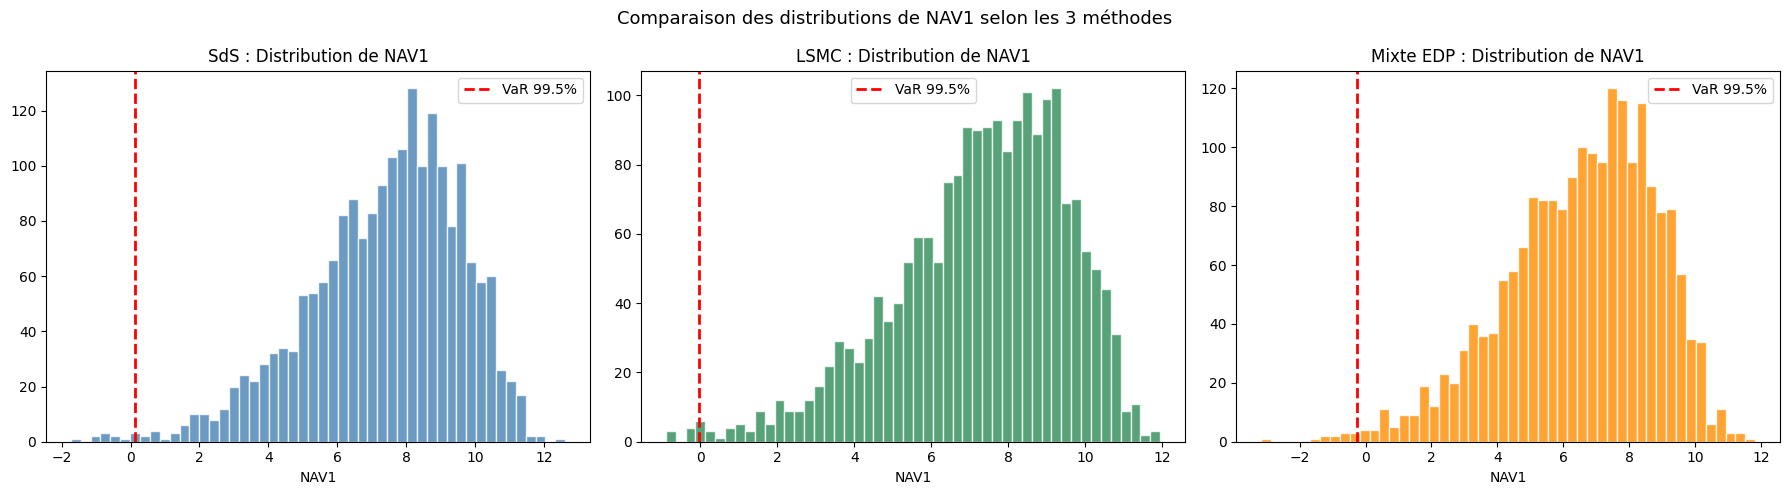


--- Tableau comparatif ---
Méthode                     SCR    Temps (s)
---------------------------------------------
SdS.................     6.2188         0.31
LSMC................     6.3689         0.18
Mixte EDP...........     6.5898         0.74


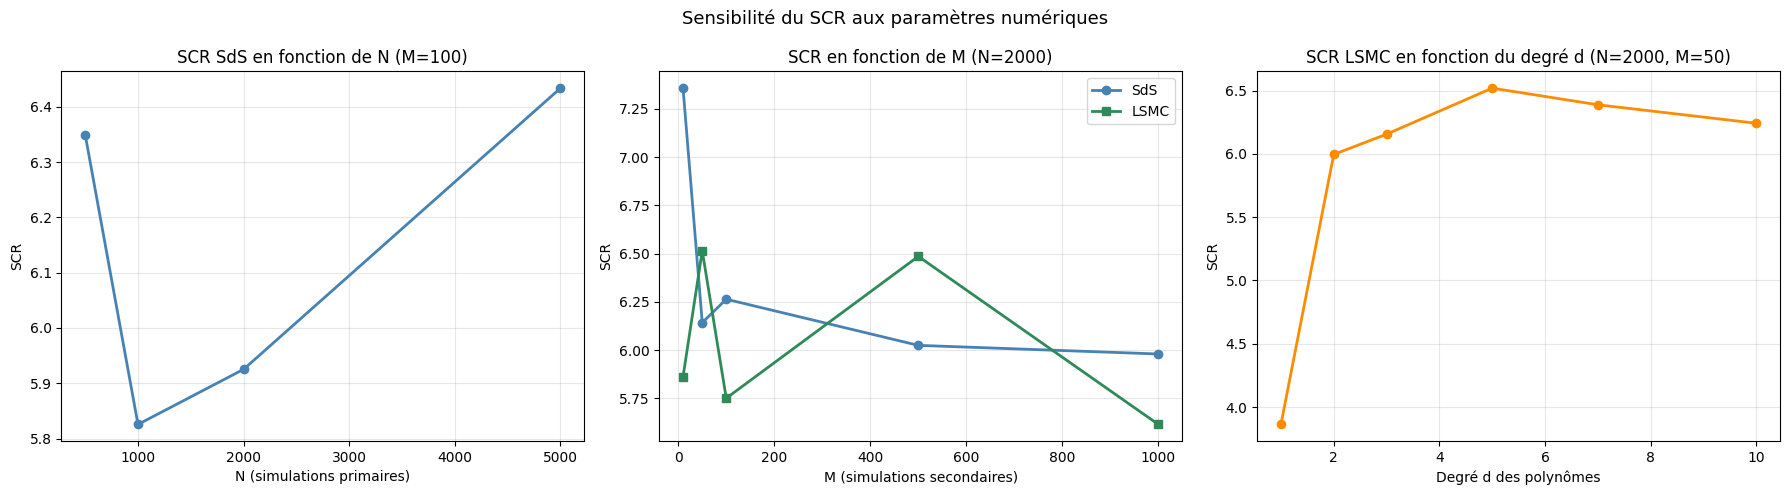

In [ ]:

# QUESTION 2 : COMPARAISON ET VISUALISATION

print("\n" + "="*60)
print("COMPARAISON DES MÉTHODES")
print("="*60)

# Comparaison des distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(NAV1_SdS, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.percentile(NAV1_SdS, 0.5), color='red', linestyle='--', linewidth=2, label='VaR 99.5%')
axes[0].set_title('SdS : Distribution de NAV1')
axes[0].set_xlabel('NAV1')
axes[0].legend()

axes[1].hist(NAV1_LSMC, bins=50, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].axvline(np.percentile(NAV1_LSMC, 0.5), color='red', linestyle='--', linewidth=2, label='VaR 99.5%')
axes[1].set_title('LSMC : Distribution de NAV1')
axes[1].set_xlabel('NAV1')
axes[1].legend()

axes[2].hist(NAV1_mixte, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[2].axvline(np.percentile(NAV1_mixte, 0.5), color='red', linestyle='--', linewidth=2, label='VaR 99.5%')
axes[2].set_title('Mixte EDP : Distribution de NAV1')
axes[2].set_xlabel('NAV1')
axes[2].legend()

plt.suptitle('Comparaison des distributions de NAV1 selon les 3 méthodes', fontsize=13)
plt.tight_layout()
plt.show()

# Tableau comparatif
print("\n--- Tableau comparatif ---")
print(f"{'Méthode':<20} {'SCR':>10} {'Temps (s)':>12}")
print("-" * 45)
print(f"{'SdS':.<20} {SCR_SdS:>10.4f} {t_SdS:>12.2f}")
print(f"{'LSMC':.<20} {SCR_LSMC:>10.4f} {t_LSMC:>12.2f}")
print(f"{'Mixte EDP':.<20} {SCR_mixte:>10.4f} {t_mixte:>12.2f}")

# Graphiques sensibilité à N et M
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(liste_N, SCR_vs_N, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('SCR SdS en fonction de N (M=100)')
axes[0].set_xlabel('N (simulations primaires)')
axes[0].set_ylabel('SCR')
axes[0].grid(True, alpha=0.3)

axes[1].plot(liste_M, SCR_vs_M_SdS, 'o-', color='steelblue', label='SdS', linewidth=2)
axes[1].plot(liste_M, SCR_vs_M_LSMC, 's-', color='seagreen', label='LSMC', linewidth=2)
axes[1].set_title('SCR en fonction de M (N=2000)')
axes[1].set_xlabel('M (simulations secondaires)')
axes[1].set_ylabel('SCR')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(liste_degre, SCR_vs_degre, 'o-', color='darkorange', linewidth=2)
axes[2].set_title('SCR LSMC en fonction du degré d (N=2000, M=50)')
axes[2].set_xlabel('Degré d des polynômes')
axes[2].set_ylabel('SCR')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Sensibilité du SCR aux paramètres numériques', fontsize=13)
plt.tight_layout()
plt.show()




SENSIBILITÉS DU SCR (MÉTHODE LSMC)


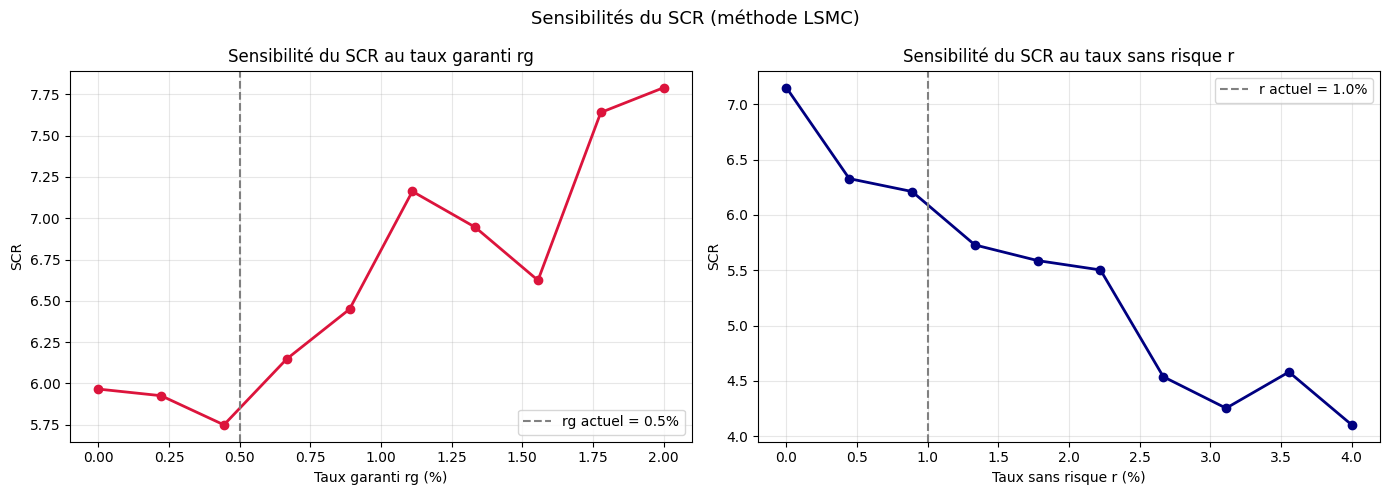


Sensibilité au taux garanti rg :
  rg=0.00% -> SCR=5.9661
  rg=0.22% -> SCR=5.9259
  rg=0.44% -> SCR=5.7495
  rg=0.67% -> SCR=6.1483
  rg=0.89% -> SCR=6.4494
  rg=1.11% -> SCR=7.1624
  rg=1.33% -> SCR=6.9455
  rg=1.56% -> SCR=6.6241
  rg=1.78% -> SCR=7.6398
  rg=2.00% -> SCR=7.7898

Sensibilité au taux sans risque r :
  r=0.00% -> SCR=7.1504
  r=0.44% -> SCR=6.3284
  r=0.89% -> SCR=6.2117
  r=1.33% -> SCR=5.7290
  r=1.78% -> SCR=5.5873
  r=2.22% -> SCR=5.5026
  r=2.67% -> SCR=4.5374
  r=3.11% -> SCR=4.2529
  r=3.56% -> SCR=4.5802
  r=4.00% -> SCR=4.1022

=== FIN DU PROJET ===


In [ ]:

# QUESTION 3 : SENSIBILITÉS (LSMC)

print("\n" + "="*60)
print("SENSIBILITÉS DU SCR (MÉTHODE LSMC)")
print("="*60)

# Sensibilité au taux garanti rg
liste_rg = np.linspace(0.0, 0.02, 10)
SCR_vs_rg = []

for rg_test in liste_rg:
    # Mise à jour globale des paramètres
    r_g_old = r_g
    K_test = R * VM0 * np.exp(rg_test * T) - (1 - x) * R * VM0 * np.exp(r * T)

    # Recalcul NAV0 avec rg_test
    valeur_BE0_test = R * VM0 * (x * S0 + (1 - x))
    valeur_put0_test = prix_put_bs(nominal_risque * S0, K_test, r, sigma_i, T)
    NAV0_test = VM0 - valeur_BE0_test - valeur_put0_test

    # LSMC avec le nouveau K
    N_sensi, M_sensi, d_sensi = 2000, 50, 5
    S1_sim = simuler_sous_jacent(S0, N_sensi, dt=1, sigma=sigma_r, derive=mu)
    NAV1_bruitee = np.zeros(N_sensi)

    for k in range(N_sensi):
        S1_k = S1_sim[k]
        ST_sim = simuler_sous_jacent(S1_k, M_sensi, dt=T - 1, sigma=sigma_i, derive=r)
        VM_T_k = VM0 * (x * ST_sim + (1 - x) * np.exp(r * T))
        BE_T_k = R * VM0 * (x * ST_sim + (1 - x) * np.exp(r * T))
        put_T_k = np.maximum(K_test - nominal_risque * ST_sim, 0)
        NAV1_bruitee[k] = np.exp(-r * (T - 1)) * np.mean(VM_T_k - BE_T_k - put_T_k)

    S1_norm, _, _ = normaliser_S(S1_sim)
    Phi = base_legendre(S1_norm, d_sensi)
    alpha_test, _, _, _ = np.linalg.lstsq(Phi, NAV1_bruitee, rcond=None)
    NAV1_fit = Phi @ alpha_test
    VaR_test = np.percentile(NAV1_fit / (1 + r), 0.5)
    SCR_vs_rg.append(NAV0_test - VaR_test)

# Sensibilité au taux sans risque r
liste_r = np.linspace(0.0, 0.04, 10)
SCR_vs_r = []

for r_test in liste_r:
    K_test = R * VM0 * np.exp(r_g * T) - (1 - x) * R * VM0 * np.exp(r_test * T)

    valeur_BE0_test = R * VM0 * (x * S0 + (1 - x))
    valeur_put0_test = prix_put_bs(nominal_risque * S0, K_test, r_test, sigma_i, T)
    NAV0_test = VM0 - valeur_BE0_test - valeur_put0_test

    N_sensi, M_sensi, d_sensi = 2000, 50, 5
    S1_sim = simuler_sous_jacent(S0, N_sensi, dt=1, sigma=sigma_r, derive=mu)
    NAV1_bruitee = np.zeros(N_sensi)

    for k in range(N_sensi):
        S1_k = S1_sim[k]
        ST_sim = simuler_sous_jacent(S1_k, M_sensi, dt=T - 1, sigma=sigma_i, derive=r_test)
        VM_T_k = VM0 * (x * ST_sim + (1 - x) * np.exp(r_test * T))
        BE_T_k = R * VM0 * (x * ST_sim + (1 - x) * np.exp(r_test * T))
        put_T_k = np.maximum(K_test - nominal_risque * ST_sim, 0)
        NAV1_bruitee[k] = np.exp(-r_test * (T - 1)) * np.mean(VM_T_k - BE_T_k - put_T_k)

    S1_norm, _, _ = normaliser_S(S1_sim)
    Phi = base_legendre(S1_norm, d_sensi)
    alpha_test, _, _, _ = np.linalg.lstsq(Phi, NAV1_bruitee, rcond=None)
    NAV1_fit = Phi @ alpha_test
    VaR_test = np.percentile(NAV1_fit / (1 + r_test), 0.5)
    SCR_vs_r.append(NAV0_test - VaR_test)

# Graphiques des sensibilités
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(liste_rg * 100, SCR_vs_rg, 'o-', color='crimson', linewidth=2)
axes[0].axvline(r_g * 100, color='gray', linestyle='--', label=f'rg actuel = {r_g*100}%')
axes[0].set_title('Sensibilité du SCR au taux garanti rg')
axes[0].set_xlabel('Taux garanti rg (%)')
axes[0].set_ylabel('SCR')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(liste_r * 100, SCR_vs_r, 'o-', color='navy', linewidth=2)
axes[1].axvline(r * 100, color='gray', linestyle='--', label=f'r actuel = {r*100}%')
axes[1].set_title('Sensibilité du SCR au taux sans risque r')
axes[1].set_xlabel('Taux sans risque r (%)')
axes[1].set_ylabel('SCR')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sensibilités du SCR (méthode LSMC)', fontsize=13)
plt.tight_layout()
plt.show()

print("\nSensibilité au taux garanti rg :")
for rg_v, scr_v in zip(liste_rg, SCR_vs_rg):
    print(f"  rg={rg_v*100:.2f}% -> SCR={scr_v:.4f}")

print("\nSensibilité au taux sans risque r :")
for r_v, scr_v in zip(liste_r, SCR_vs_r):
    print(f"  r={r_v*100:.2f}% -> SCR={scr_v:.4f}")

